# Streamflow Data Availability Analysis (Post 1 Jan 2016)

This notebook analyzes valid streamflow observation data availability for **14,729 basins** across dataset sources (USGS, HYSETS, GRDC, CAMELS, CAMELSGB, CAMELSAUS, CAMELSFR, CAMELSBR, CAMELSCL).

**Dataset**: `streamflow_by_internal_ids_20260210_right_labeled.zarr`

In [9]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path to local Zarr store
zarr_path = "/usr/local/google/home/kruparell/flood-forecasting/googlehydrology/streamflow_by_internal_ids_20260210_right_labeled.zarr"

# Open Zarr dataset
ds = xr.open_zarr(zarr_path)

# Slice for dates >= 2016-01-01
ds_post2016 = ds.sel(time=slice("2016-01-01", None))
total_possible_days = len(ds_post2016.time)

print(f"Dataset loaded. Time range: {ds_post2016.time.values[0]} to {ds_post2016.time.values[-1]}")
print(f"Total possible observation days post-2016: {total_possible_days}")

Dataset loaded. Time range: 2016-01-01T00:00:00.000000000 to 2025-10-06T00:00:00.000000000
Total possible observation days post-2016: 3567


In [10]:
# Compute count of non-null streamflow observations per gauge
valid_days = ds_post2016["streamflow"].notnull().sum(dim="time").values

# Parse source groups from gauge IDs
def get_source_group(gid: str) -> str:
    parts = gid.split("_")
    if parts[0] == "CARAVAN" and len(parts) > 1:
        return parts[1]  # HYSETS, CAMELS, CAMELSGB, etc.
    return parts[0]      # USGS, GRDC

# Build DataFrame
df_availability = pd.DataFrame({
    "gauge_id": ds.gauge_id.values,
    "source_group": [get_source_group(g) for g in ds.gauge_id.values],
    "valid_days": valid_days,
    "coverage_pct": (valid_days / total_possible_days) * 100
})

print(f"Computed availability for {len(df_availability):,} gauges.")
print(f"Gauges with at least 1 valid day post-2016: {(df_availability['valid_days'] > 0).sum():,} / {len(df_availability):,}")

Computed availability for 14,729 gauges.
Gauges with at least 1 valid day post-2016: 11,653 / 14,729


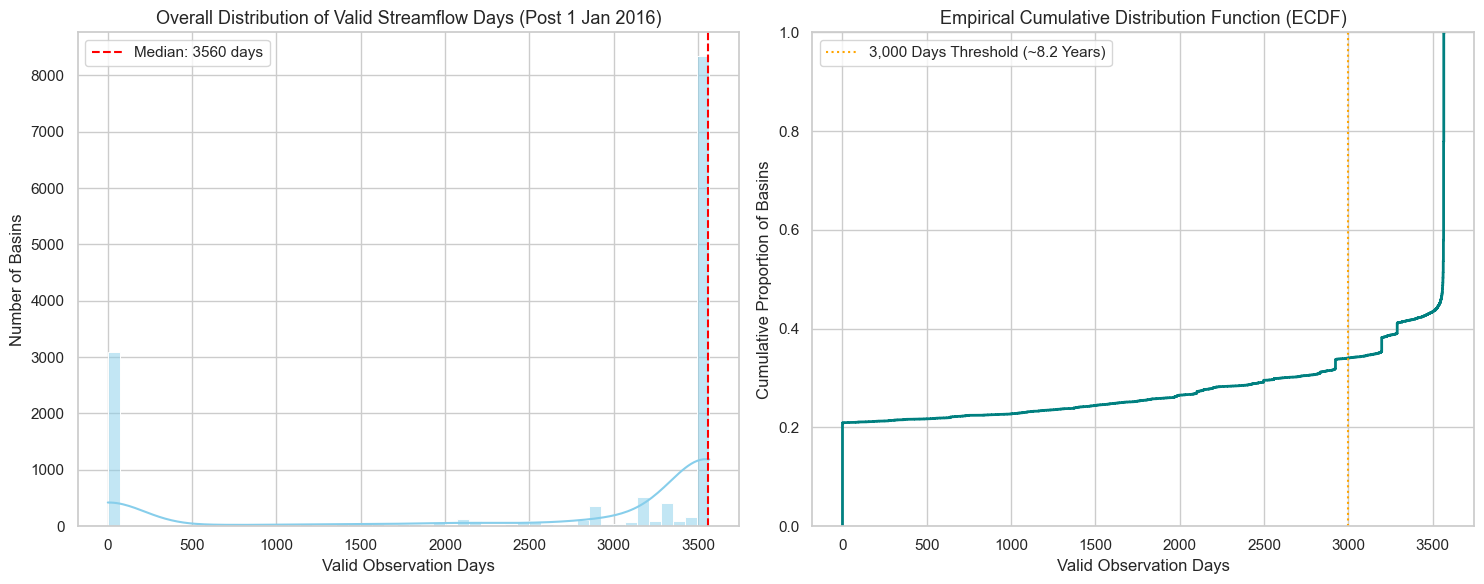

In [11]:
# Overall Data Availability Visualizations (Histogram & ECDF)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

med_val = df_availability["valid_days"].median()

# Left: Overall Histogram of Valid Days
sns.histplot(df_availability["valid_days"], bins=50, kde=True, ax=axes[0], color="skyblue")
axes[0].axvline(med_val, color="red", linestyle="--", label=f"Median: {med_val:.0f} days")
axes[0].set_title("Overall Distribution of Valid Streamflow Days (Post 1 Jan 2016)", fontsize=13)
axes[0].set_xlabel("Valid Observation Days")
axes[0].set_ylabel("Number of Basins")
axes[0].legend()

# Right: Cumulative Distribution (ECDF)
sns.ecdfplot(df_availability["valid_days"], ax=axes[1], color="teal", lw=2)
axes[1].axvline(3000, color="orange", linestyle=":", label="3,000 Days Threshold (~8.2 Years)")
axes[1].set_title("Empirical Cumulative Distribution Function (ECDF)", fontsize=13)
axes[1].set_xlabel("Valid Observation Days")
axes[1].set_ylabel("Cumulative Proportion of Basins")
axes[1].legend()

plt.tight_layout()
plt.show()

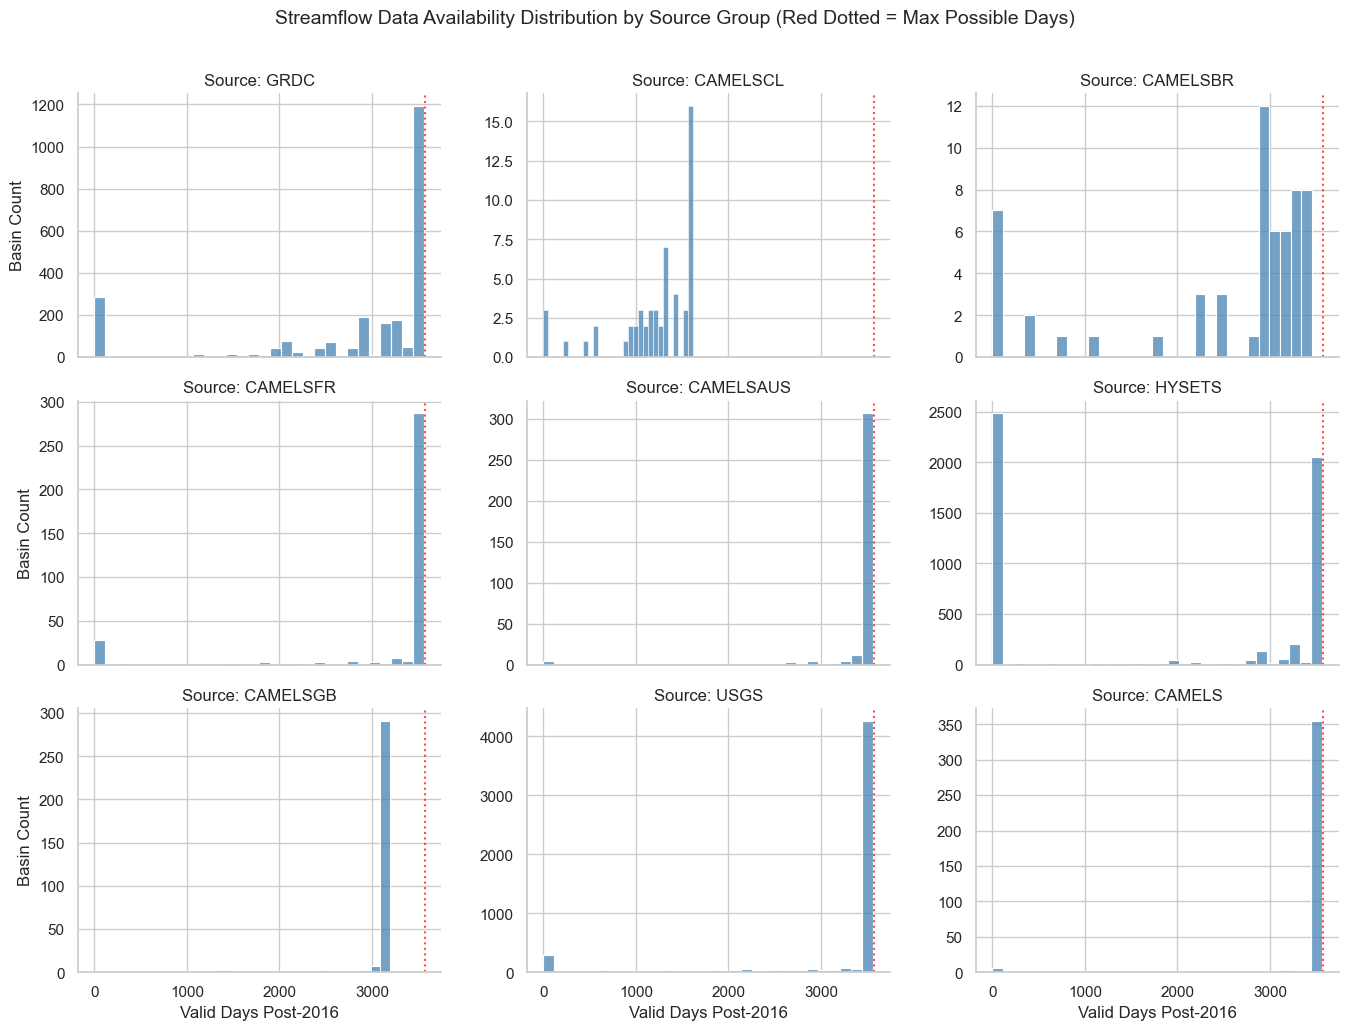

In [12]:
# Faceted Histograms of Valid Days by Source Group
g = sns.FacetGrid(df_availability, col="source_group", col_wrap=3, height=3.5, aspect=1.3, sharey=False)
g.map(sns.histplot, "valid_days", bins=30, color="steelblue", edgecolor="white", kde=False)

g.set_axis_labels("Valid Days Post-2016", "Basin Count")
g.set_titles(col_template="Source: {col_name}", size=12)

for ax in g.axes.flat:
    ax.axvline(total_possible_days, color="red", linestyle=":", alpha=0.7)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Streamflow Data Availability Distribution by Source Group (Red Dotted = Max Possible Days)", fontsize=14)
plt.show()

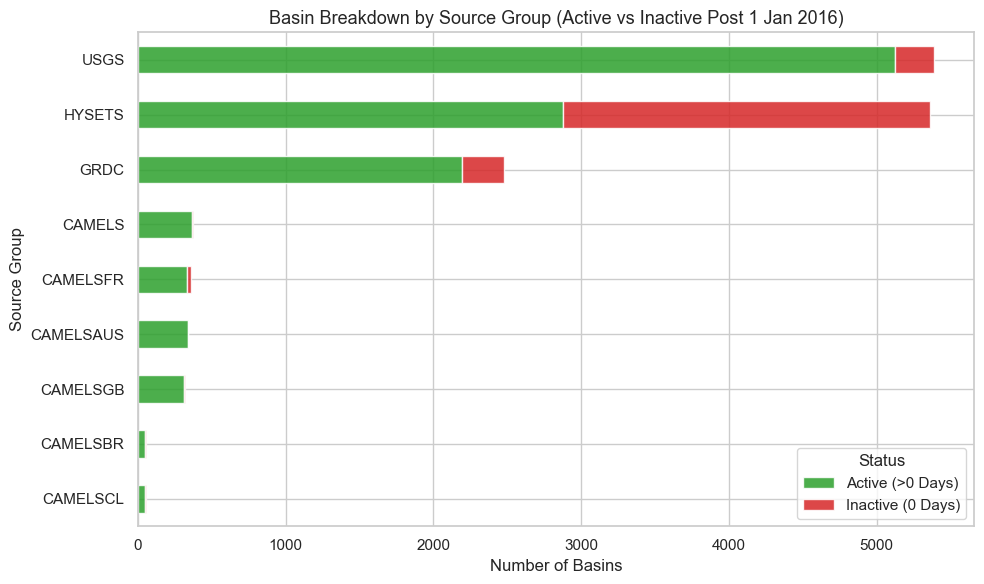

In [13]:
# Gauge Coverage Breakdown Bar Chart (Active vs Inactive)
df_availability["status"] = np.where(df_availability["valid_days"] > 0, "Active (>0 Days)", "Inactive (0 Days)")
group_counts = df_availability.groupby(["source_group", "status"]).size().unstack(fill_value=0)
group_counts["Total"] = group_counts.sum(axis=1)
group_counts = group_counts.sort_values(by="Total", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
group_counts[["Active (>0 Days)", "Inactive (0 Days)"]].plot(
    kind="barh", stacked=True, ax=ax, color=["#2ca02c", "#d62728"], alpha=0.85
)

ax.set_title("Basin Breakdown by Source Group (Active vs Inactive Post 1 Jan 2016)", fontsize=13)
ax.set_xlabel("Number of Basins")
ax.set_ylabel("Source Group")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

In [14]:
# Summary Statistics Table by Source Group
summary_table = df_availability.groupby("source_group").agg(
    total_gauges=("valid_days", "count"),
    active_gauges=("valid_days", lambda x: (x > 0).sum()),
    mean_valid_days=("valid_days", "mean"),
    median_valid_days=("valid_days", "median"),
    avg_coverage_pct=("coverage_pct", "mean")
).reset_index()

summary_table["active_pct"] = (summary_table["active_gauges"] / summary_table["total_gauges"]) * 100
summary_table = summary_table.sort_values(by="total_gauges", ascending=False).reset_index(drop=True)

# Display formatted table
pd.set_option('display.float_format', lambda x: '%.1f' % x)
print("=== Data Availability Summary by Source Group (Post 1 Jan 2016) ===")
summary_table

=== Data Availability Summary by Source Group (Post 1 Jan 2016) ===


,source_group,total_gauges,active_gauges,mean_valid_days,median_valid_days,avg_coverage_pct,active_pct
0,USGS,5388,5120,3147.3,3564.0,88.2,95.0
1,HYSETS,5357,2880,1748.8,1966.0,49.0,53.8
2,GRDC,2477,2194,2802.4,3341.0,78.6,88.6
3,CAMELS,375,369,3468.8,3564.0,97.2,98.4
4,CAMELSFR,359,332,3133.1,3564.0,87.8,92.5
5,CAMELSAUS,342,338,3454.9,3561.5,96.9,98.8
6,CAMELSGB,317,316,3106.0,3197.0,87.1,99.7
7,CAMELSBR,59,52,2494.2,2984.0,69.9,88.1
8,CAMELSCL,55,52,1211.9,1302.0,34.0,94.5


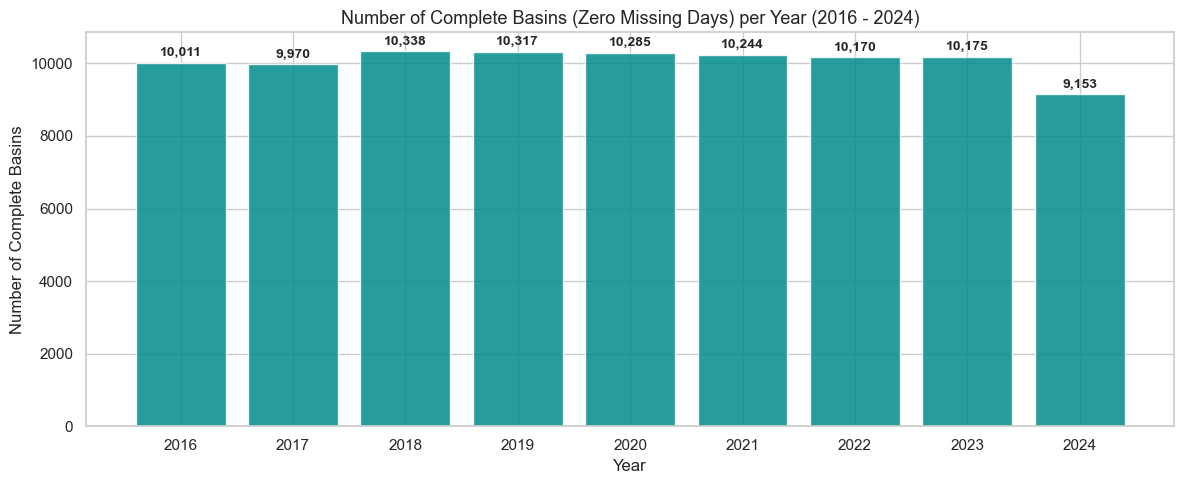

=== Yearly Complete Basins Summary ===


,Year,Days in Year,Complete Basins (100% Data),Completeness %
0,2016,366,10011,68.0
1,2017,365,9970,67.7
2,2018,365,10338,70.2
3,2019,365,10317,70.0
4,2020,366,10285,69.8
5,2021,365,10244,69.5
6,2022,365,10170,69.0
7,2023,365,10175,69.1
8,2024,366,9153,62.1


In [15]:
# Yearly Complete Basins Analysis (Zero Missing Days per Year)
years = range(2016, 2025)  # 2016 to 2024
valid_mask = ds["streamflow"].notnull()

yearly_completeness = []
for y in years:
    ds_y = valid_mask.sel(time=str(y))
    total_days_in_year = len(ds_y.time)
    valid_count_per_gauge = ds_y.sum(dim="time").values
    complete_count = (valid_count_per_gauge == total_days_in_year).sum()
    yearly_completeness.append({
        "Year": y,
        "Days in Year": total_days_in_year,
        "Complete Basins (100% Data)": int(complete_count),
        "Completeness %": (complete_count / len(ds.gauge_id.values)) * 100
    })

df_yearly_completeness = pd.DataFrame(yearly_completeness)

# Plot Yearly Complete Basin Counts
fig, ax1 = plt.subplots(figsize=(12, 5))
bars = ax1.bar(df_yearly_completeness["Year"], df_yearly_completeness["Complete Basins (100% Data)"], color="darkcyan", alpha=0.85)
ax1.set_title("Number of Complete Basins (Zero Missing Days) per Year (2016 - 2024)", fontsize=13)
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Complete Basins")
ax1.set_xticks(years)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 100, f"{int(yval):,}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

print("=== Yearly Complete Basins Summary ===")
display(df_yearly_completeness)

In [16]:
# Helper Functions to Filter Complete Basins for Any Specified Year(s)

def get_complete_basins(year: int, min_completeness_pct: float = 100.0) -> pd.DataFrame:
    """Returns DataFrame of basins with complete data for a specified year."""
    ds_y = ds["streamflow"].sel(time=str(year))
    total_days = len(ds_y.time)
    valid_days = ds_y.notnull().sum(dim="time").values
    pct = (valid_days / total_days) * 100
    
    mask = pct >= min_completeness_pct
    return pd.DataFrame({
        "gauge_id": ds.gauge_id.values[mask],
        "source_group": [get_source_group(g) for g in ds.gauge_id.values[mask]],
        "valid_days": valid_days[mask],
        "total_days_in_year": total_days,
        "completeness_pct": pct[mask]
    })

def get_complete_basins_across_years(start_year: int = 2016, end_year: int = 2024) -> pd.DataFrame:
    """Returns basins that are 100% complete across ALL years in range [start_year, end_year]."""
    ds_range = ds["streamflow"].sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    total_days = len(ds_range.time)
    valid_days = ds_range.notnull().sum(dim="time").values
    
    mask = (valid_days == total_days)
    return pd.DataFrame({
        "gauge_id": ds.gauge_id.values[mask],
        "source_group": [get_source_group(g) for g in ds.gauge_id.values[mask]],
        "valid_days": valid_days[mask],
        "total_days_in_period": total_days
    })

# --- Example 1: Filter complete basins for 2020 ---
df_complete_2020 = get_complete_basins(2020)
print(f"Complete basins in 2020: {len(df_complete_2020):,}")
print("Source breakdown for 2020 complete basins:")
print(df_complete_2020["source_group"].value_counts())
display(df_complete_2020.head())

# --- Example 2: Filter basins with 100% data continuously from 2016 to 2024 ---
df_complete_all = get_complete_basins_across_years(2016, 2024)
print(f"\nBasins with 100% complete data continuously from 2016 to 2024: {len(df_complete_all):,}")
print("Source breakdown for continuously complete basins (2016-2024):")
print(df_complete_all["source_group"].value_counts())

Complete basins in 2020: 10,285
Source breakdown for 2020 complete basins:
source_group
USGS         4577
HYSETS       2527
GRDC         1877
CAMELS        361
CAMELSAUS     305
CAMELSFR      299
CAMELSGB      295
CAMELSBR       44
Name: count, dtype: int64


,gauge_id,source_group,valid_days,total_days_in_year,completeness_pct
0,GRDC_2588558,GRDC,366,366,100.0
1,GRDC_2589320,GRDC,366,366,100.0
2,GRDC_2590101,GRDC,366,366,100.0
3,GRDC_2587230,GRDC,366,366,100.0
4,GRDC_2588920,GRDC,366,366,100.0



Basins with 100% complete data continuously from 2016 to 2024: 7,370
Source breakdown for continuously complete basins (2016-2024):
source_group
USGS         3643
HYSETS       1911
GRDC         1078
CAMELS        311
CAMELSFR      235
CAMELSAUS     186
CAMELSBR        6
Name: count, dtype: int64


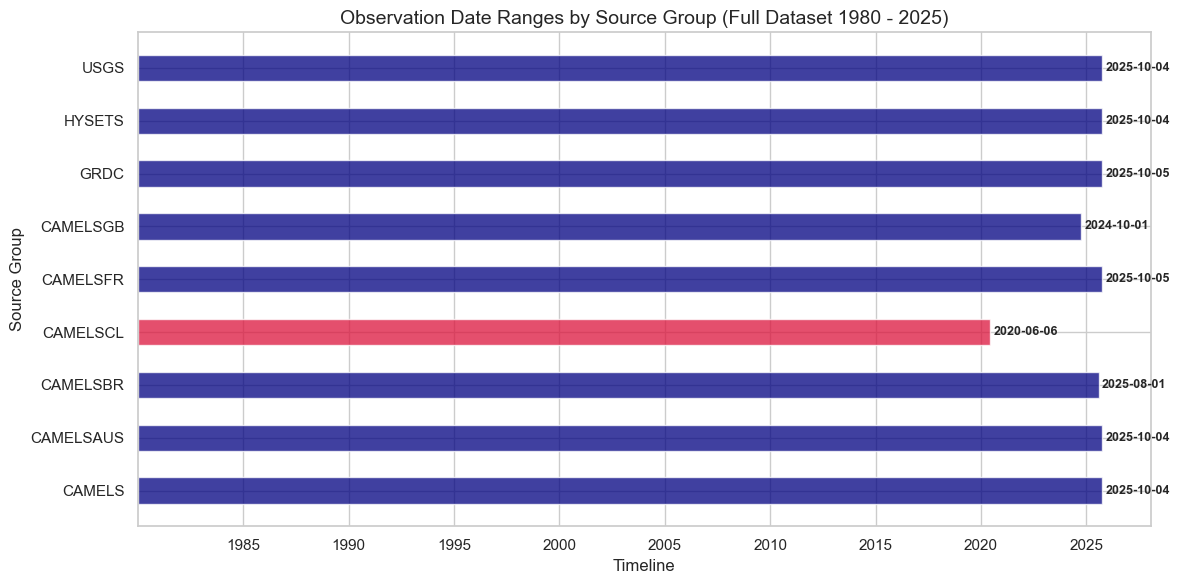

=== Earliest and Latest Observation Dates by Source Group ===


,Source Group,Total Gauges,Earliest Observation,Latest Observation,Status / Note
0,CAMELS,375,1980-01-02,2025-10-04,Active up to Oct 2025
1,CAMELSAUS,342,1980-01-02,2025-10-04,Active up to Oct 2025
2,CAMELSBR,59,1980-01-02,2025-08-01,Stops at 2025-08-01
3,CAMELSCL,55,1980-01-02,2020-06-06,⚠️ Chilean data STOPS at 2020-06-06
4,CAMELSFR,359,1980-01-02,2025-10-05,Active up to Oct 2025
5,CAMELSGB,317,1980-01-02,2024-10-01,Stops at 2024-10-01
6,GRDC,2477,1980-01-02,2025-10-05,Active up to Oct 2025
7,HYSETS,5357,1980-01-02,2025-10-04,Active up to Oct 2025
8,USGS,5388,1980-01-02,2025-10-04,Active up to Oct 2025


In [17]:
# Earliest and Latest Available Observation Dates by Source Group
gauge_ids = ds.gauge_id.values
gauge_sources = np.array([get_source_group(g) for g in gauge_ids])
unique_sources = sorted(list(set(gauge_sources)))
time_vals = ds.time.values

source_date_boundaries = []
for sg in unique_sources:
    indices = np.where(gauge_sources == sg)[0]
    sub_ds = ds["streamflow"].isel(gauge_id=indices)
    valid_any = sub_ds.notnull().any(dim="gauge_id").values
    if not valid_any.any():
        continue
    valid_times = time_vals[valid_any]
    earliest = pd.Timestamp(valid_times[0]).strftime("%Y-%m-%d")
    latest = pd.Timestamp(valid_times[-1]).strftime("%Y-%m-%d")
    
    note = "Active up to Oct 2025"
    if sg == "CAMELSCL":
        note = "⚠️ Chilean data STOPS at 2020-06-06"
    elif sg == "CAMELSGB":
        note = "Stops at 2024-10-01"
    elif sg == "CAMELSBR":
        note = "Stops at 2025-08-01"
        
    source_date_boundaries.append({
        "Source Group": sg,
        "Total Gauges": len(indices),
        "Earliest Observation": earliest,
        "Latest Observation": latest,
        "Status / Note": note
    })

df_boundaries = pd.DataFrame(source_date_boundaries)

# Plot Observation Date Ranges per Source Group
fig, ax = plt.subplots(figsize=(12, 6))
for idx, row in df_boundaries.iterrows():
    start_dt = pd.to_datetime(row["Earliest Observation"])
    end_dt = pd.to_datetime(row["Latest Observation"])
    color = "crimson" if row["Source Group"] == "CAMELSCL" else "navy"
    ax.barh(row["Source Group"], (end_dt - start_dt).days, left=start_dt, color=color, alpha=0.75, height=0.5)
    ax.text(end_dt + pd.Timedelta(days=60), idx, row["Latest Observation"], va="center", fontsize=9, fontweight="bold")

ax.set_title("Observation Date Ranges by Source Group (Full Dataset 1980 - 2025)", fontsize=14)
ax.set_xlabel("Timeline")
ax.set_ylabel("Source Group")
plt.tight_layout()
plt.show()

print("=== Earliest and Latest Observation Dates by Source Group ===")
display(df_boundaries)